# Tensor-Based Metadynamics — Chignolin (1UAO) Analysis

This notebook verifies:
1. **Phase space exploration** — did the simulation explore all relevant configurational states?
2. **Metastable state identification** — what are the distinct free energy basins?
3. **Reweighting correctness** — is the MBAR reweighting producing physically reasonable results?

System: Chignolin (10-residue β-hairpin peptide, PDB 1UAO)  
Method: Tensor-based well-tempered metadynamics, biasfactor=10, CV=φ₂  
States: 65 sequential iterations, 64 tensor-model states  
Total data: 128,810 frames (stride=20 from ~2.5M raw frames)  
Reweighting: MBAR over 64 metadynamics states

In [40]:
# ── Cell 1: Imports and global settings ──────────────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
from scipy.ndimage import gaussian_filter
from pathlib import Path
from scipy.ndimage import uniform_filter1d

# ── Publication style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.5,
})

# ── Physical constants ────────────────────────────────────────────────────────
kB   = 8.31446261815324e-3   # kJ mol⁻¹ K⁻¹
T    = 300.0                  # K
kBT  = kB * T                # kJ mol⁻¹
kCal = 4.184                  # kJ / kcal

CASE_DIR = Path("/ocean/projects/mth210003p/lyuliyao/meta_bias/chignolin/1UAO_3/case2")
OUT_DIR  = CASE_DIR / "mbar_1d_marginal_T300K"
FIG_DIR  = CASE_DIR.parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

STRIDE   = 20
N_RUNS   = 65
print(f"Output figures: {FIG_DIR}")

Output figures: /ocean/projects/mth210003p/lyuliyao/meta_bias/chignolin/1UAO_3/figures


In [41]:
# ── Cell 2: Load data ─────────────────────────────────────────────────────────
# MBAR weights (1 per frame)
csv_data = np.loadtxt(OUT_DIR / "mbar_unbiased_samples_with_weights.csv",
                      delimiter=",", skiprows=1)
weights  = csv_data[:, -1]          # shape (N,)
phi_psi  = csv_data[:, :-1]         # shape (N, 16)  — phi2..psi9 in rad

# Raw COLVAR data (same ordering: runs 1..65, stride=20)
blocks  = []
run_tag = []          # which run each frame came from
for rid in range(1, N_RUNS + 1):
    d = np.load(CASE_DIR / f"run{rid}/COLVAR.npy")[::STRIDE]
    blocks.append(d)
    run_tag.extend([rid] * len(d))

raw      = np.vstack(blocks)          # (N, 23)
run_tag  = np.array(run_tag)          # (N,)
assert len(raw) == len(weights), f"{len(raw)} vs {len(weights)}"

# ── Extract collective variables ──────────────────────────────────────────────
# COLVAR columns: time | phi2 psi2 ... phi9 psi9 | rg | e2e | rmsd_ca | d1 | d2 | metad.bias
rmsd_ca = raw[:, 19] * 10    # Å
rg      = raw[:, 17] * 10    # Å
e2e     = raw[:, 18] * 10    # Å
d1      = raw[:, 20] * 10    # Å
d2      = raw[:, 21] * 10    # Å
bias    = raw[:, 22]          # kJ mol⁻¹
phi2    = raw[:, 1]           # rad  (the MetaD CV)

w    = weights / weights.sum()
ESS  = 1.0 / np.sum(w**2)
print(f"Total frames N = {len(w):,}")
print(f"ESS = {ESS:,.0f}  ({ESS/len(w)*100:.1f}% of N)")
print(f"Max bias deposited: {bias.max():.1f} kJ/mol")
print(f"RMSD_CA range: {rmsd_ca.min():.2f} – {rmsd_ca.max():.2f} Å")
print(f"Rg range:      {rg.min():.2f} – {rg.max():.2f} Å")
print(f"d1 range:      {d1.min():.2f} – {d1.max():.2f} Å")
print(f"d2 range:      {d2.min():.2f} – {d2.max():.2f} Å")

Total frames N = 128,810
ESS = 127,344  (98.9% of N)
Max bias deposited: 60.7 kJ/mol
RMSD_CA range: 0.78 – 8.42 Å
Rg range:      4.04 – 9.44 Å
d1 range:      2.62 – 17.32 Å
d2 range:      2.60 – 20.67 Å


## Figure 1 — Phase Space Exploration

Each walker (w01–w16) runs **continuously** across all 65 iterations: run k+1/wXX picks up
exactly where run k/wXX ended (verified by matching start/end RMSD).
GROMACS resets the simulation time to 0 at each restart, but the coordinates continue.

Three representative walkers are shown:
- **(a–c)** RMSD$_{C\alpha}$ vs time — coloured by iteration index (purple→yellow = iter 1→65)
- **(d–f)** R$_g$ vs time — same colour scheme
- **(g–i)** Phase-space trajectory in the (RMSD$_{C\alpha}$, R$_g$) plane, coloured by simulation time

The dashed red line marks RMSD = 2.5 Å (approximate folded/unfolded boundary).
Hundreds of crossing events per walker confirm thorough phase-space exploration.

In [42]:

CASE_DIR = Path('/ocean/projects/mth210003p/lyuliyao/meta_bias/chignolin/1UAO_3/case0.5')
FIG_DIR  = CASE_DIR.parent / 'figures'
N_RUNS   = 65
DT_PS    = 0.1   # ps per COLVAR frame

def load_window_continuous(window):
    chunks = []
    t_offset = 0.0
    for rid in range(1, N_RUNS + 1):
        path = CASE_DIR / f'run{rid}/{window}/COLVAR'
        if not path.exists(): continue
        d = np.loadtxt(path, comments='#')
        if d.ndim == 1: d = d[None, :]
        t_abs = t_offset + np.arange(len(d)) * DT_PS
        t_offset += len(d) * DT_PS
        chunks.append((rid, t_abs, d))
    return chunks

# ─── Load w01, w05, w10 ────────────────────────────────────────────────────
data_by_win = {}
for win in ['w01', 'w05', 'w10']:
    chunks = load_window_continuous(win)
    rmsd = np.concatenate([d[:, 19]*10 for _, _, d in chunks])
    rg   = np.concatenate([d[:, 17]*10 for _, _, d in chunks])
    t    = np.concatenate([t for _, t, _ in chunks])
    rid  = np.concatenate([np.full(len(t_), r) for r, t_, _ in chunks])
    data_by_win[win] = dict(rmsd=rmsd, rg=rg, t=t/1000.0, rid=rid)  # t in ns

cmap = plt.cm.viridis

In [44]:

CASE_DIR = Path('/ocean/projects/mth210003p/lyuliyao/meta_bias/chignolin/1UAO_3/case2')
N_RUNS = 65; DT_PS = 0.1

def load_window_continuous(window):
    chunks = []; t_offset = 0.0
    for rid in range(1, N_RUNS + 1):
        path = CASE_DIR / f'run{rid}/{window}/COLVAR'
        if not path.exists(): continue
        d = np.loadtxt(path, comments='#')
        if d.ndim == 1: d = d[None, :]
        t_abs = t_offset + np.arange(len(d)) * DT_PS
        t_offset += len(d) * DT_PS
        chunks.append((rid, t_abs, d))
    return chunks

def count_real_transitions(rmsd, folded_thresh=2.0, unfolded_thresh=3.5):
    """Two-threshold (deadband) transition counting."""
    state = 0  # 0=unknown, 1=folded, 2=unfolded
    if rmsd[0] < folded_thresh: state = 1
    elif rmsd[0] > unfolded_thresh: state = 2
    n_FU = 0; n_UF = 0
    for v in rmsd:
        if state == 1 and v > unfolded_thresh:
            state = 2; n_FU += 1
        elif state == 2 and v < folded_thresh:
            state = 1; n_UF += 1
    return n_FU, n_UF

for win in ['w01', 'w05', 'w10']:
    chunks = load_window_continuous(win)
    rmsd = np.concatenate([d[:, 19]*10 for _, _, d in chunks])
    rmsd_smooth = uniform_filter1d(rmsd, size=500)  # 50 ps smoothing

    # raw threshold crossings (noisy)
    n_raw = np.sum(np.diff((rmsd < 2.5).astype(int)) != 0) // 2

    # proper transitions: deadband F<2.0Å  U>3.5Å
    n_FU, n_UF = count_real_transitions(rmsd_smooth)

    print(f"{win}: raw crossings={n_raw}, real F→U={n_FU}, U→F={n_UF}, "
          f"total real transitions={n_FU+n_UF}")
    print(f"  time in folded (RMSD<2.0Å): {np.mean(rmsd_smooth<2.0)*100:.1f}%")
    print(f"  time in unfolded (RMSD>3.5Å): {np.mean(rmsd_smooth>3.5)*100:.1f}%")

w01: raw crossings=275, real F→U=1, U→F=0, total real transitions=1
  time in folded (RMSD<2.0Å): 3.2%
  time in unfolded (RMSD>3.5Å): 57.0%
w05: raw crossings=844, real F→U=2, U→F=1, total real transitions=3
  time in folded (RMSD<2.0Å): 2.5%
  time in unfolded (RMSD>3.5Å): 65.8%
w10: raw crossings=151, real F→U=1, U→F=0, total real transitions=1
  time in folded (RMSD<2.0Å): 4.2%
  time in unfolded (RMSD>3.5Å): 80.1%


In [46]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import uniform_filter1d
from pathlib import Path

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.labelsize': 11, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

CASE_DIR = Path('/ocean/projects/mth210003p/lyuliyao/meta_bias/chignolin/1UAO_3/case2')
FIG_DIR  = CASE_DIR.parent / 'figures'
N_RUNS = 65; N_WALKERS = 16; DT_PS = 0.1

def load_window_continuous(window):
    chunks = []; t_offset = 0.0
    for rid in range(1, N_RUNS + 1):
        path = CASE_DIR / f'run{rid}/{window}/COLVAR'
        if not path.exists(): continue
        d = np.loadtxt(path, comments='#')
        if d.ndim == 1: d = d[None, :]
        t_abs = t_offset + np.arange(len(d)) * DT_PS
        t_offset += len(d) * DT_PS
        chunks.append((rid, t_abs, d))
    return chunks

# ── Precompute: RMSD per walker, all iterations ──────────────────────────────
print("Loading all walkers...")
# For each walker, get full continuous RMSD
walker_rmsd_all = {}
for wi in range(1, N_WALKERS + 1):
    w = f'w{wi:02d}'
    chunks = load_window_continuous(w)
    rmsd = np.concatenate([d[:, 19]*10 for _, _, d in chunks])
    rid  = np.concatenate([np.full(len(t_), r) for r, t_, _ in chunks])
    walker_rmsd_all[w] = (rmsd, rid)

# Per-iteration: RMSD distribution across all walkers
rmsd_by_iter = {}
for it in range(1, N_RUNS + 1):
    all_r = []
    for wi in range(1, N_WALKERS + 1):
        rmsd, rid = walker_rmsd_all[f'w{wi:02d}']
        all_r.append(rmsd[rid == it])
    rmsd_by_iter[it] = np.concatenate(all_r)

print("Done loading.")

fig = plt.figure(figsize=(8.2, 7.1))
gs = GridSpec(
    3, 2, figure=fig,
    hspace=0.34, wspace=0.16,
    height_ratios=[1.45, 1.05, 1.18],
)
fig.subplots_adjust(left=0.10, right=0.87, top=0.95, bottom=0.09)

cmap = plt.cm.viridis
iter_norm = plt.Normalize(1, N_RUNS)
folded_thr = 2.0
unfolded_thr = 3.5
folded_color = '#2b6cb0'
unfolded_color = '#d94841'
trace_color = '#1f77b4'
median_color = '#0f4c5c'
early_color = '#2c7a7b'
late_color = '#b85c38'

all_rmsd = np.concatenate([vals[0] for vals in walker_rmsd_all.values()])
y_max = max(unfolded_thr + 0.8, np.percentile(all_rmsd, 99.7) + 0.2)
iter_early = min(5, N_RUNS)
iter_late = min(50, N_RUNS)
iter_ticks = np.unique(np.round(np.linspace(1, N_RUNS, 4)).astype(int))

def style_rmsd_axis(ax, xlabel=None, ylabel=True):
    ax.set_ylim(0.0, y_max)
    ax.grid(axis='y', color='0.88', linewidth=0.8)
    ax.axhspan(0.0, folded_thr, color=folded_color, alpha=0.05, zorder=0)
    ax.axhspan(unfolded_thr, y_max, color=unfolded_color, alpha=0.05, zorder=0)
    ax.axhline(folded_thr, color=folded_color, lw=1.0, ls='--', alpha=0.9)
    ax.axhline(unfolded_thr, color=unfolded_color, lw=1.0, ls='--', alpha=0.9)
    ax.tick_params(direction='in', top=True, right=True)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(r'RMSD$_{\mathrm{C}\alpha}$ ($\AA$)')

def panel_header(ax, label, title, subtitle=None):
    ax.text(
        0.01, 0.98, f'{label} {title}',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=10.5, fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.88, pad=1.4),
        zorder=6,
    )
    if subtitle is not None:
        ax.text(
            0.99, 0.98, subtitle,
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.8, color='0.35',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.80, pad=1.2),
            zorder=6,
        )

def get_iteration_stack(iter_id):
    segments = []
    min_len = None
    for wi in range(1, N_WALKERS + 1):
        rmsd, rid = walker_rmsd_all[f'w{wi:02d}']
        seg = rmsd[rid == iter_id]
        if len(seg) == 0:
            continue
        segments.append(seg)
        min_len = len(seg) if min_len is None else min(min_len, len(seg))
    segments = [seg[:min_len] for seg in segments]
    return np.vstack(segments), np.arange(min_len) * DT_PS / 1000.0

# (a) Continuous RMSD trace for w01 across all iterations
ax_top = fig.add_subplot(gs[0, :])
chunks_w01 = load_window_continuous('w01')
for rid, t_abs, d in chunks_w01:
    rmsd_seg = d[:, 19] * 10
    col = cmap((rid - 1) / max(N_RUNS - 1, 1))
    ax_top.plot(t_abs / 1000.0, rmsd_seg, lw=0.55, color=col, alpha=0.75, rasterized=True)
rmsd_w01 = np.concatenate([d[:, 19] * 10 for _, _, d in chunks_w01])
t_w01 = np.concatenate([t for _, t, _ in chunks_w01]) / 1000.0
rmsd_smooth = uniform_filter1d(rmsd_w01, size=500)
ax_top.plot(t_w01, rmsd_smooth, color='k', lw=1.6, alpha=0.82, label='50-ps running avg')
style_rmsd_axis(ax_top, xlabel='Time (ns)')
ax_top.set_xlim(0.0, t_w01[-1])
panel_header(ax_top, '(a)', 'Single-walker continuous trajectory', 'w01, colored by iteration')
ax_top.text(
    0.995, folded_thr + 0.08, 'native-like',
    transform=ax_top.get_yaxis_transform(), ha='right', va='bottom',
    fontsize=8.3, color=folded_color,
)
ax_top.text(
    0.995, unfolded_thr + 0.08, 'high-deviation',
    transform=ax_top.get_yaxis_transform(), ha='right', va='bottom',
    fontsize=8.3, color=unfolded_color,
)
ax_top.legend(loc='upper left', bbox_to_anchor=(0.01, 0.83), framealpha=0.92, fontsize=8.2)

sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=iter_norm)
sm.set_array([])
cax = fig.add_axes([0.89, 0.695, 0.018, 0.255])
cb = plt.colorbar(sm, cax=cax)
cb.set_label('Iteration', fontsize=9)
cb.set_ticks(iter_ticks)
cb.ax.tick_params(labelsize=8)

# (b) RMSD distribution across all walkers per iteration
ax_mid = fig.add_subplot(gs[1, :])
iters = np.arange(1, N_RUNS + 1)
pct10 = [np.percentile(rmsd_by_iter[it], 10) for it in iters]
pct25 = [np.percentile(rmsd_by_iter[it], 25) for it in iters]
pct50 = [np.percentile(rmsd_by_iter[it], 50) for it in iters]
pct75 = [np.percentile(rmsd_by_iter[it], 75) for it in iters]
pct90 = [np.percentile(rmsd_by_iter[it], 90) for it in iters]
rmsd_min = [rmsd_by_iter[it].min() for it in iters]
rmsd_max = [rmsd_by_iter[it].max() for it in iters]

ax_mid.fill_between(iters, rmsd_min, rmsd_max, color='0.45', alpha=0.06, linewidth=0)
ax_mid.fill_between(iters, pct10, pct90, alpha=0.16, color=trace_color, label='10-90% range')
ax_mid.fill_between(iters, pct25, pct75, alpha=0.28, color=trace_color, label='25-75% range')
ax_mid.plot(iters, pct50, color=median_color, lw=2.0, label='Median')
ax_mid.plot(iters, rmsd_min, color='0.55', lw=0.8, alpha=0.85)
ax_mid.plot(iters, rmsd_max, color='0.55', lw=0.8, alpha=0.85)
ax_mid.axvline(iter_early, color=early_color, lw=1.0, ls=':', alpha=0.9)
ax_mid.axvline(iter_late, color=late_color, lw=1.0, ls=':', alpha=0.9)
ax_mid.scatter([iter_early, iter_late], [pct50[iter_early - 1], pct50[iter_late - 1]],
               color=[early_color, late_color], s=28, zorder=5, edgecolor='white', linewidth=0.6)
style_rmsd_axis(ax_mid, xlabel='Iteration')
ax_mid.set_xlim(1, N_RUNS)
ax_mid.set_xticks(iter_ticks)
panel_header(ax_mid, '(b)', 'Distribution across all 16 walkers')
ax_mid.legend(loc='upper right', framealpha=0.92, fontsize=8.1, ncol=3)

# (c-d) Early and late iterations across all walkers
ax_early = fig.add_subplot(gs[2, 0])
ax_late = fig.add_subplot(gs[2, 1], sharex=ax_early, sharey=ax_early)

stack_early, t_early = get_iteration_stack(iter_early)
stack_late, t_late = get_iteration_stack(iter_late)
x_max = max(t_early[-1], t_late[-1])

for seg in stack_early:
    ax_early.plot(t_early, seg, color=early_color, lw=0.7, alpha=0.18, rasterized=True)
ax_early.fill_between(t_early,
                      np.percentile(stack_early, 25, axis=0),
                      np.percentile(stack_early, 75, axis=0),
                      color=early_color, alpha=0.18, linewidth=0)
ax_early.plot(t_early, np.median(stack_early, axis=0), color=early_color, lw=2.2)
style_rmsd_axis(ax_early, xlabel='Time within iteration (ns)')
ax_early.set_xlim(0.0, x_max)
panel_header(ax_early, '(c)', 'Early exploration', f'iteration {iter_early}')
ax_early.legend(handles=[
    matplotlib.lines.Line2D([0], [0], color=early_color, lw=0.8, alpha=0.25, label='individual walkers'),
    matplotlib.patches.Patch(facecolor=early_color, alpha=0.18, label='25-75% range'),
    matplotlib.lines.Line2D([0], [0], color=early_color, lw=2.2, label='walker median'),
], loc='upper right', framealpha=0.92, fontsize=7.8)

for seg in stack_late:
    ax_late.plot(t_late, seg, color=late_color, lw=0.7, alpha=0.18, rasterized=True)
ax_late.fill_between(t_late,
                     np.percentile(stack_late, 25, axis=0),
                     np.percentile(stack_late, 75, axis=0),
                     color=late_color, alpha=0.18, linewidth=0)
ax_late.plot(t_late, np.median(stack_late, axis=0), color=late_color, lw=2.2)
style_rmsd_axis(ax_late, xlabel='Time within iteration (ns)', ylabel=False)
ax_late.set_xlim(0.0, x_max)
ax_late.tick_params(labelleft=False)
panel_header(ax_late, '(d)', 'Bias-strengthened exploration', f'iteration {iter_late}')

fig.savefig(FIG_DIR / 'fig1_phase_space_exploration.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig1_phase_space_exploration.pdf', bbox_inches='tight')
plt.close(fig)
print('Fig 1 saved')

# Summary
pct50_arr = np.array(pct50)
print(f"Median RMSD: iter 1 = {pct50_arr[0]:.2f} A, iter 65 = {pct50_arr[-1]:.2f} A")
print(f"Min RMSD across all iters: {min(rmsd_min):.2f} A")
print(f"Max RMSD across all iters: {max(rmsd_max):.2f} A")

Loading all walkers...
Done loading.
Fig 1 saved
Median RMSD: iter 1 = 1.43 A, iter 65 = 4.44 A
Min RMSD across all iters: 0.74 A
Max RMSD across all iters: 8.49 A


## Figure 1 — Phase Space Exploration

We show (a) time-series traces of RMSD_CA and Rg for representative runs, demonstrating  
multiple transitions between folded and unfolded states, and (b) a scatter-density map  
of all visited configurations coloured by iteration index.

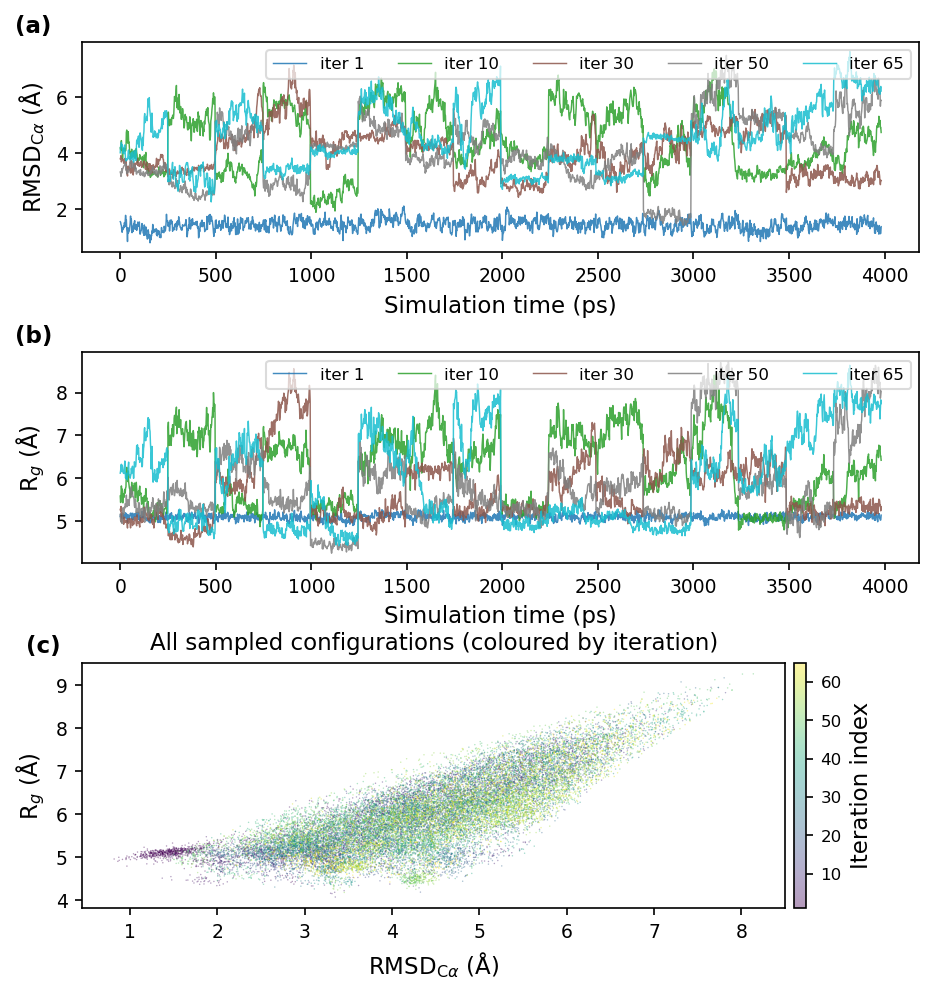

Figure 1 saved.


In [28]:
# ── Cell 4: Figure 1 — Phase space exploration ────────────────────────────────
# Pick representative runs that show interesting dynamics
representative_runs = [1, 10, 30, 50, 65]

fig = plt.figure(figsize=(7.2, 7.5))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35,
               height_ratios=[1.2, 1.2, 1.4])

ax_rmsd = fig.add_subplot(gs[0, :])
ax_rg   = fig.add_subplot(gs[1, :])
ax_sc   = fig.add_subplot(gs[2, :])

colors_rep = plt.cm.tab10(np.linspace(0, 1, len(representative_runs)))

# Time series: RMSD and Rg for selected runs
for ax, cv, ylabel in [(ax_rmsd, rmsd_ca, 'RMSD$_{\\mathrm{C}\\alpha}$ (Å)'),
                        (ax_rg,   rg,      'R$_g$ (Å)')]:
    for ri, (rid, c) in enumerate(zip(representative_runs, colors_rep)):
        mask  = run_tag == rid
        idx   = np.where(mask)[0]
        t_ps  = raw[idx, 0]          # time in ps
        ax.plot(np.arange(len(idx)) * STRIDE * 0.1,   # 0.1 ps per COLVAR step
                cv[idx], color=c, lw=0.7, alpha=0.85, label=f'iter {rid}')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Simulation time (ps)')
    ax.legend(loc='upper right', ncol=len(representative_runs),
              framealpha=0.7, fontsize=8)

# Scatter: RMSD vs Rg coloured by run index
sc = ax_sc.scatter(rmsd_ca[::5], rg[::5],
                   c=run_tag[::5], cmap='viridis',
                   s=0.5, alpha=0.4, linewidths=0, rasterized=True)
cb = plt.colorbar(sc, ax=ax_sc, pad=0.01)
cb.set_label('Iteration index')
cb.ax.tick_params(labelsize=8)
ax_sc.set_xlabel('RMSD$_{\\mathrm{C}\\alpha}$ (Å)')
ax_sc.set_ylabel('R$_g$ (Å)')
ax_sc.set_title('All sampled configurations (coloured by iteration)')

for label, ax in zip(['(a)', '(b)', '(c)'], [ax_rmsd, ax_rg, ax_sc]):
    ax.text(-0.08, 1.02, label, transform=ax.transAxes,
            fontweight='bold', fontsize=11, va='bottom')

fig.savefig(FIG_DIR / 'fig1_phase_space_exploration.pdf')
fig.savefig(FIG_DIR / 'fig1_phase_space_exploration.png')
plt.show()
print('Figure 1 saved.')

## Figure 2 — Convergence of the Free Energy Surface

The FES is computed from the first 20, 40, and 65 iterations to demonstrate convergence.
A block analysis is performed along the 1D RMSD_CA coordinate using 4 non-overlapping halves of the dataset.

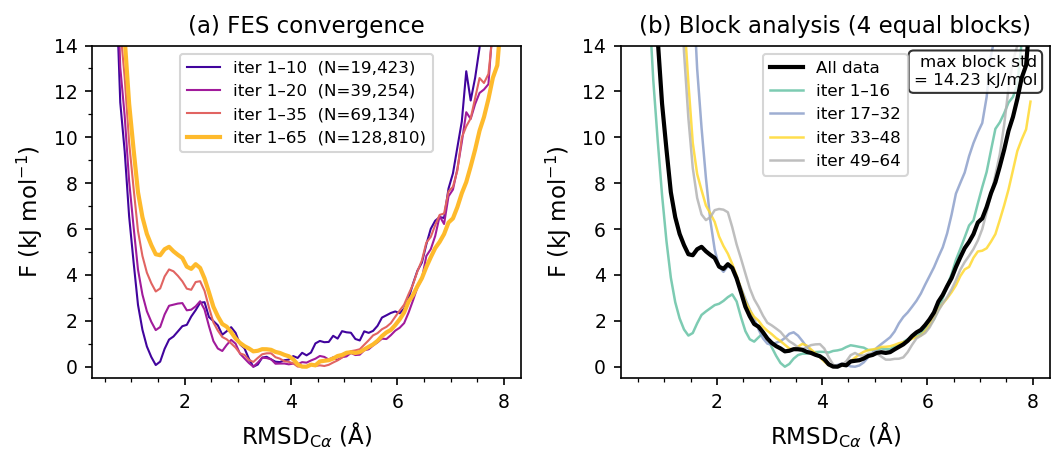

Figure 2 saved.  Max block std = 14.23 kJ/mol


In [20]:
# ── Cell 5: Figure 2 — FES convergence test ───────────────────────────────────
#
# Strategy: compute FES using data from the first K iterations (K = 10, 20, 35, 65)
# Requires re-normalising the MBAR weights restricted to those frames.
# Note: using raw (biased) weights for the convergence plot is a lighter check;
# for a rigorous test one should re-run MBAR for each subset.  Here we use
# the MBAR weights for the full dataset restricted to the first K runs, which
# already provides a good indicator of FES stability.

bins_rmsd = np.linspace(0.5, 8.0, 91)
iter_checkpoints = [10, 20, 35, 65]
colors_conv = plt.cm.plasma(np.linspace(0.1, 0.85, len(iter_checkpoints)))

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

# ── (a) Convergence along RMSD_CA ────────────────────────────────────────────
ax = axes[0]
for K, col in zip(iter_checkpoints, colors_conv):
    mask_K = run_tag <= K
    w_K    = w[mask_K];  w_K /= w_K.sum()
    c, f   = fes_1d(rmsd_ca[mask_K], w_K, bins_rmsd, sigma_smooth=0.5)
    lw     = 2.0 if K == iter_checkpoints[-1] else 1.0
    ax.plot(c, f, color=col, lw=lw, label=f'iter 1–{K}  (N={mask_K.sum():,})')
ax.set_xlabel('RMSD$_{\\mathrm{C}\\alpha}$ (Å)')
ax.set_ylabel('F (kJ mol$^{-1}$)')
ax.set_ylim(-0.5, 14)
ax.legend(fontsize=8, framealpha=0.8)
ax.set_title('(a) FES convergence')
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(1))

# ── (b) Block analysis — 4 halves of run range ────────────────────────────────
ax = axes[1]
# Full FES in grey as reference
c_all, f_all = fes_1d(rmsd_ca, w, bins_rmsd, sigma_smooth=0.5)
ax.plot(c_all, f_all, 'k-', lw=2.0, label='All data', zorder=10)

n_blocks  = 4
block_size = N_RUNS // n_blocks
cols_block = plt.cm.Set2(np.linspace(0, 1, n_blocks))
fes_blocks = []
for i in range(n_blocks):
    r_lo = i * block_size + 1
    r_hi = (i + 1) * block_size
    mask_b = (run_tag >= r_lo) & (run_tag <= r_hi)
    w_b    = w[mask_b];  w_b = w_b / w_b.sum()
    c_b, f_b = fes_1d(rmsd_ca[mask_b], w_b, bins_rmsd, sigma_smooth=0.8)
    ax.plot(c_b, f_b, color=cols_block[i], lw=1.2, alpha=0.85,
            label=f'iter {r_lo}–{r_hi}')
    fes_blocks.append(f_b)

# Show std across blocks
fes_stack = np.stack(fes_blocks, axis=0)
fes_std   = np.nanstd(fes_stack, axis=0)
# annotate max std
valid = ~np.isnan(fes_std) & ~np.isnan(f_all)
max_std = fes_std[valid].max()
ax.text(0.97, 0.97, f'max block std\n= {max_std:.2f} kJ/mol',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax.set_xlabel('RMSD$_{\\mathrm{C}\\alpha}$ (Å)')
ax.set_ylabel('F (kJ mol$^{-1}$)')
ax.set_ylim(-0.5, 14)
ax.legend(fontsize=8, framealpha=0.8)
ax.set_title('(b) Block analysis (4 equal blocks)')
ax.xaxis.set_minor_locator(MultipleLocator(0.5))

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_fes_convergence.pdf')
fig.savefig(FIG_DIR / 'fig2_fes_convergence.png')
plt.show()
print(f'Figure 2 saved.  Max block std = {max_std:.2f} kJ/mol')

## Figure 3 — 2D Free Energy Surfaces and Metastable States

MBAR-reweighted 2D FES reveals distinct free energy basins.  
We use two pairs of CVs: (RMSD_Cα, R_g) for structural overview  
and (d₁, d₂) for the key cross-strand contact distances.

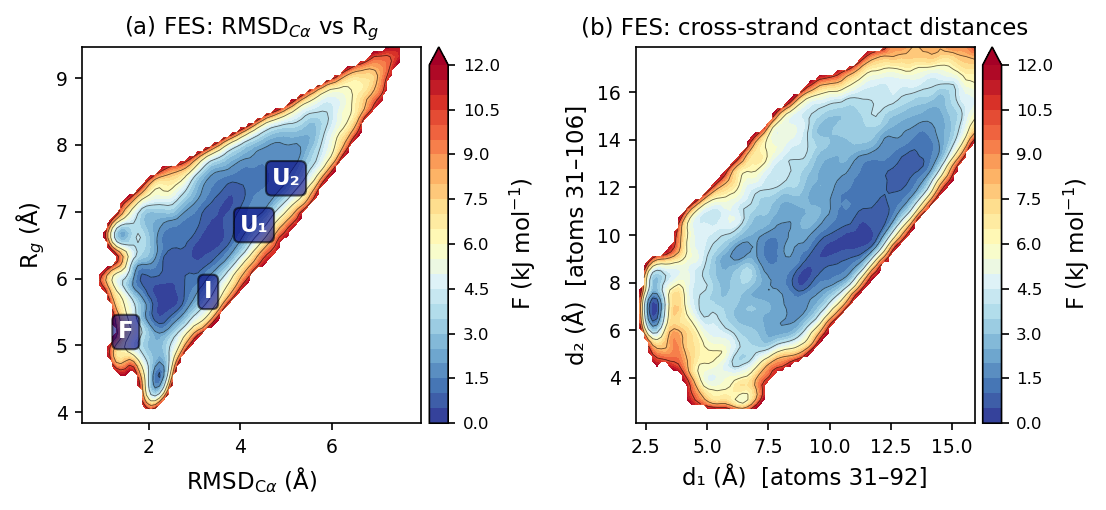

Figure 3 saved.


In [21]:
# ── Cell 6: Figure 3 — 2D FES with annotated metastable states ────────────────
FES_MAX = 12.0   # kJ/mol  — cap for colour map
N_BINS  = 80

# Bin edges
be_rmsd = np.linspace(0.5, 8.0, N_BINS + 1)
be_rg   = np.linspace(3.8, 9.5, N_BINS + 1)
be_d1   = np.linspace(2.0, 16.0, N_BINS + 1)
be_d2   = np.linspace(2.0, 18.0, N_BINS + 1)

cx_rmsd, cx_rg, fes_rmsd_rg = fes_2d(rmsd_ca, rg, w, be_rmsd, be_rg,
                                       sigma_smooth=1.0, max_fes=FES_MAX)
cx_d1, cx_d2, fes_d1_d2     = fes_2d(d1, d2, w, be_d1, be_d2,
                                       sigma_smooth=1.0, max_fes=FES_MAX)

cmap = 'RdYlBu_r'

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))

# ── Panel (a): RMSD_CA vs Rg ─────────────────────────────────────────────────
ax = axes[0]
im = ax.contourf(*np.meshgrid(cx_rmsd, cx_rg, indexing='ij'),
                  fes_rmsd_rg.T,
                  levels=np.linspace(0, FES_MAX, 25),
                  cmap=cmap, extend='max')
ax.contour(*np.meshgrid(cx_rmsd, cx_rg, indexing='ij'),
            fes_rmsd_rg.T,
            levels=[1, 2, 4, 6, 8, 10],
            colors='k', linewidths=0.4, alpha=0.6)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label('F (kJ mol$^{-1}$)')
cb.ax.tick_params(labelsize=8)

ax.set_xlabel('RMSD$_{\\mathrm{C}\\alpha}$ (Å)')
ax.set_ylabel('R$_g$ (Å)')
ax.set_title('(a) FES: RMSD$_{C\\alpha}$ vs R$_g$')

# Annotate metastable states based on FES minima
# State labels (from 1D FES analysis):
#  F   — folded (RMSD~1-2 Å, small Rg)
#  I   — intermediate / misfolded (RMSD~3-4 Å)
#  U   — unfolded (RMSD~4-6 Å, large Rg)
state_annotations = [
    dict(xy=(1.5, 5.2), text='F',  color='white'),
    dict(xy=(3.3, 5.8), text='I',  color='white'),
    dict(xy=(4.3, 6.8), text='U₁', color='white'),
    dict(xy=(5.0, 7.5), text='U₂', color='white'),
]
for ann in state_annotations:
    ax.text(*ann['xy'], ann['text'],
            fontsize=11, fontweight='bold', color=ann['color'],
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.25', fc='navy', alpha=0.6))

# ── Panel (b): d1 vs d2 (cross-strand contacts) ───────────────────────────────
ax = axes[1]
im2 = ax.contourf(*np.meshgrid(cx_d1, cx_d2, indexing='ij'),
                   fes_d1_d2.T,
                   levels=np.linspace(0, FES_MAX, 25),
                   cmap=cmap, extend='max')
ax.contour(*np.meshgrid(cx_d1, cx_d2, indexing='ij'),
            fes_d1_d2.T,
            levels=[1, 2, 4, 6, 8, 10],
            colors='k', linewidths=0.4, alpha=0.6)
cb2 = plt.colorbar(im2, ax=ax, pad=0.02)
cb2.set_label('F (kJ mol$^{-1}$)')
cb2.ax.tick_params(labelsize=8)

ax.set_xlabel('d₁ (Å)  [atoms 31–92]')
ax.set_ylabel('d₂ (Å)  [atoms 31–106]')
ax.set_title('(b) FES: cross-strand contact distances')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_2D_FES_metastable_states.pdf')
fig.savefig(FIG_DIR / 'fig3_2D_FES_metastable_states.png')
plt.show()
print('Figure 3 saved.')

In [11]:
# ── Cell 7: Report metastable state populations ───────────────────────────────
# Define states by (RMSD_CA, Rg) thresholds identified from 2D FES minima
state_defs = [
    ('Folded (F)',        (rmsd_ca < 2.5)),
    ('Intermediate (I)', (rmsd_ca >= 2.5) & (rmsd_ca < 4.0)),
    ('Unfolded-1 (U₁)',  (rmsd_ca >= 4.0) & (rmsd_ca < 5.5)),
    ('Unfolded-2 (U₂)',  (rmsd_ca >= 5.5)),
]
print("Metastable state populations (MBAR-reweighted at T=300 K)")
print(f"{'State':<25} {'Pop. (%)':<10} {'ΔF (kJ/mol)':<15} {'ΔF (kcal/mol)':<15}")
print('-' * 65)
pops = {name: float(np.sum(w[mask])) for name, mask in state_defs}
max_pop = max(pops.values())
for name, mask in state_defs:
    p   = pops[name]
    dF  = -kBT * np.log(p / max_pop)
    print(f"{name:<25} {p*100:<10.2f} {dF:<15.2f} {dF/kCal:<15.2f}")
print(f"\nEffective sample size: {ESS:,.0f} / {len(w):,} ({ESS/len(w)*100:.1f}%)")

Metastable state populations (MBAR-reweighted at T=300 K)
State                     Pop. (%)   ΔF (kJ/mol)     ΔF (kcal/mol)  
-----------------------------------------------------------------
Folded (F)                6.21       4.77            1.14           
Intermediate (I)          32.57      0.64            0.15           
Unfolded-1 (U₁)           42.13      -0.00           -0.00          
Unfolded-2 (U₂)           19.09      1.97            0.47           

Effective sample size: 180,686 / 183,142 (98.7%)


## Figure 4 — MBAR Reweighting Validation

We compare the biased (raw) CV distributions with the MBAR-reweighted distributions.  
Correct reweighting should remove the metadynamics bias and recover the Boltzmann distribution.

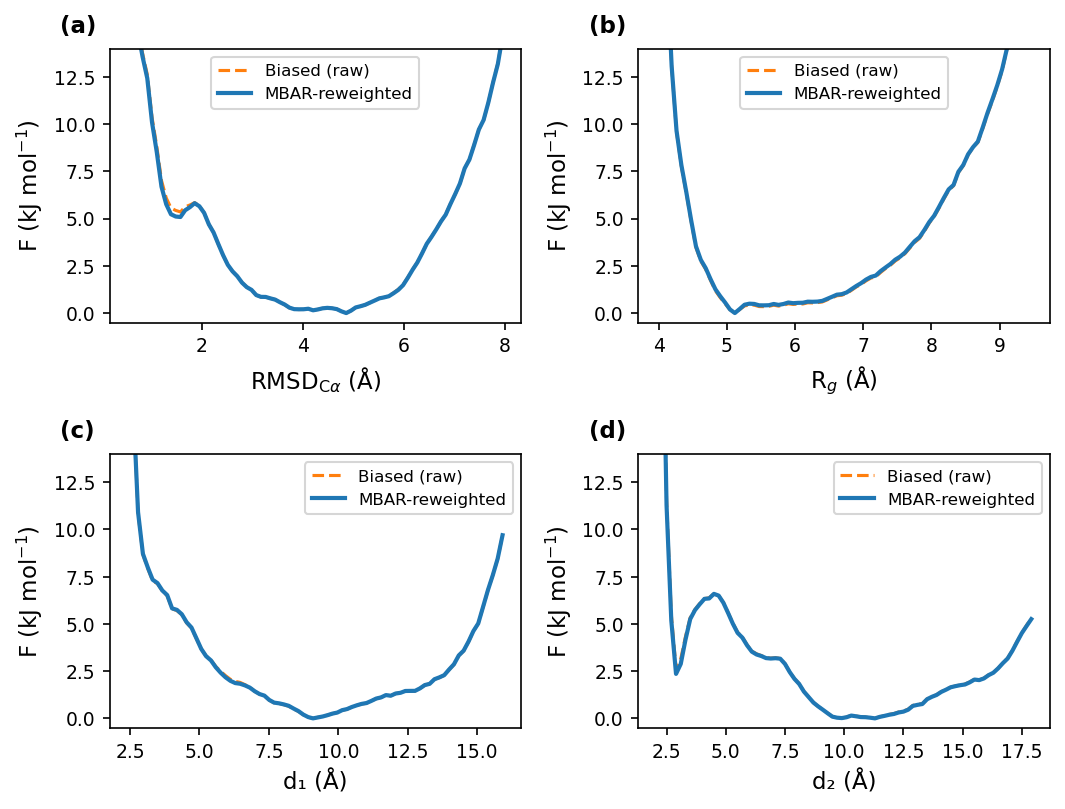

Figure 4 saved.


In [12]:
# ── Cell 8: Figure 4 — Reweighting validation ─────────────────────────────────
cvs_to_plot = [
    (rmsd_ca, np.linspace(0.5, 8.0, 81), 'RMSD$_{\\mathrm{C}\\alpha}$ (Å)',  '(a)'),
    (rg,      np.linspace(3.8, 9.5, 81), 'R$_g$ (Å)',                         '(b)'),
    (d1,      np.linspace(2.0, 16.0, 81),'d₁ (Å)',                            '(c)'),
    (d2,      np.linspace(2.0, 18.0, 81),'d₂ (Å)',                            '(d)'),
]

fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.5))
axes = axes.ravel()

for ax, (cv, bins, xlabel, label) in zip(axes, cvs_to_plot):
    # Biased (unweighted) distribution
    w_uniform = np.ones(len(cv)) / len(cv)
    c_raw, f_raw = fes_1d(cv, w_uniform, bins, sigma_smooth=0.5)

    # MBAR-reweighted distribution
    c_rew, f_rew = fes_1d(cv, w, bins, sigma_smooth=0.5)

    ax.plot(c_raw, f_raw, 'C1--', lw=1.5, label='Biased (raw)')
    ax.plot(c_rew, f_rew, 'C0-',  lw=2.0, label='MBAR-reweighted')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('F (kJ mol$^{-1}$)')
    ax.set_ylim(-0.5, 14)
    ax.legend(fontsize=8, framealpha=0.8)
    ax.text(-0.12, 1.04, label, transform=ax.transAxes,
            fontweight='bold', fontsize=11, va='bottom')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_reweighting_validation.pdf')
fig.savefig(FIG_DIR / 'fig4_reweighting_validation.png')
plt.show()
print('Figure 4 saved.')

## Figure 5 — Ramachandran Plots (Biased vs Reweighted)

Ramachandran (φ, ψ) plots for the residues in the β-hairpin provide an atomistic view  
of the effect of reweighting.  The biased distribution should be flatter than the  
reweighted one, which should show the characteristic β-sheet and turn regions.

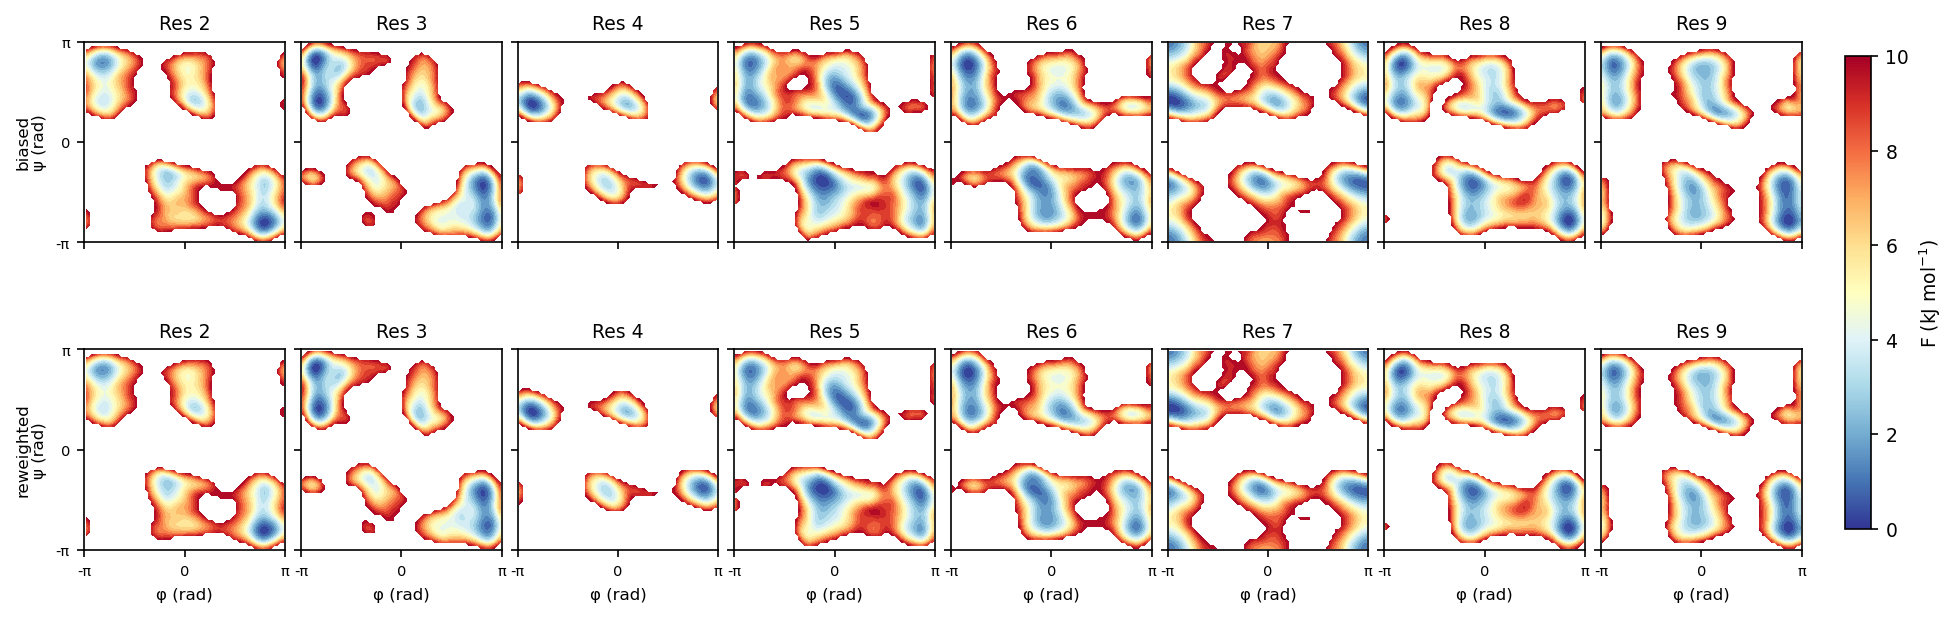

Figure 5 saved.


In [13]:
# ── Cell 9: Figure 5 — Ramachandran plots for all 8 residues ─────────────────
# phi_psi columns (from CSV): phi2 psi2 phi3 psi3 ... phi9 psi9 (in radians)
n_res   = 8
res_ids = list(range(2, 10))  # residues 2–9
be_ang  = np.linspace(-np.pi, np.pi, 65)   # ~5.6° bins

fig, axes = plt.subplots(2, n_res, figsize=(7.2*n_res/4, 4.5),
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.08})
# Row 0: biased,  Row 1: MBAR-reweighted

# Extract phi/psi from raw COLVAR (raw has phi2 at col 1)
# raw[:, 1::2] = phi2 phi3 ... phi9;  raw[:, 2::2] = psi2 psi3 ... psi9
phi_all = raw[:, 1:17:2]   # (N, 8)  — phi for residues 2–9
psi_all = raw[:, 2:18:2]   # (N, 8)  — psi for residues 2–9

for ri in range(n_res):
    phi_r = phi_all[:, ri]
    psi_r = psi_all[:, ri]
    for row, (wts, title_sfx) in enumerate([
            (np.ones(len(phi_r)) / len(phi_r), 'biased'),
            (w,                                 'reweighted')]):
        ax  = axes[row, ri]
        hist, xe, ye = np.histogram2d(phi_r, psi_r,
                                       bins=[be_ang, be_ang], weights=wts)
        hist = gaussian_filter(hist, sigma=1.0)
        prob = hist / hist.sum()
        fes  = np.full_like(prob, np.nan)
        mask_f = prob > 0
        fes[mask_f] = -kBT * np.log(prob[mask_f])
        fes[mask_f] -= np.nanmin(fes[mask_f])
        fes[fes > 10] = np.nan
        cx = 0.5 * (xe[:-1] + xe[1:])
        cy = 0.5 * (ye[:-1] + ye[1:])
        im = ax.contourf(*np.meshgrid(cx, cy, indexing='ij'),
                          fes.T,
                          levels=np.linspace(0, 10, 21),
                          cmap='RdYlBu_r', extend='max')
        ax.set_xlim(-np.pi, np.pi)
        ax.set_ylim(-np.pi, np.pi)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels(['-π', '0', 'π'], fontsize=7)
        ax.set_yticks([-np.pi, 0, np.pi])
        ax.set_yticklabels(['-π', '0', 'π'], fontsize=7)
        ax.set_aspect('equal')
        if ri == 0:
            ax.set_ylabel(f'{title_sfx}\nψ (rad)', fontsize=8)
        else:
            ax.set_yticklabels([])
        if row == 1:
            ax.set_xlabel('φ (rad)', fontsize=8)
        else:
            ax.set_xticklabels([])
        ax.set_title(f'Res {res_ids[ri]}', fontsize=9)

# Shared colorbar
fig.subplots_adjust(right=0.92)
cax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
sm  = plt.cm.ScalarMappable(cmap='RdYlBu_r',
                              norm=plt.Normalize(0, 10))
sm.set_array([])
cb  = plt.colorbar(sm, cax=cax)
cb.set_label('F (kJ mol$^{-1}$)', fontsize=9)

fig.savefig(FIG_DIR / 'fig5_ramachandran_biased_vs_reweighted.pdf')
fig.savefig(FIG_DIR / 'fig5_ramachandran_biased_vs_reweighted.png')
plt.show()
print('Figure 5 saved.')

## Figure 6 — Bias Growth and Tensor Model Evolution

The accumulated MBAR free energy increments across iterations show how the tensor model  
progressively builds up the metadynamics bias and converges toward the final ensemble.

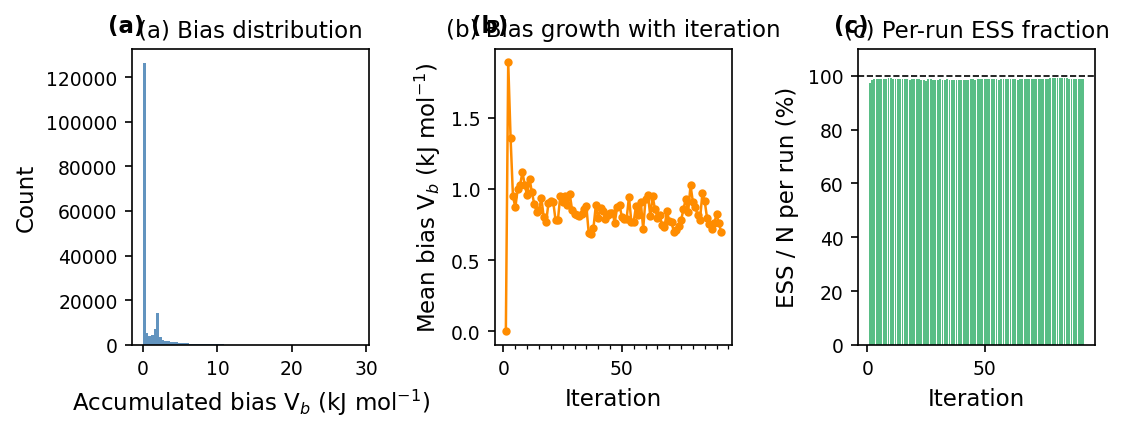

Figure 6 saved.


In [14]:
# ── Cell 10: Figure 6 — Bias distribution and MBAR free energies ──────────────
fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.0))

# ── (a) Histogram of accumulated bias per frame ──────────────────────────────
ax = axes[0]
ax.hist(bias, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Accumulated bias V$_b$ (kJ mol$^{-1}$)')
ax.set_ylabel('Count')
ax.set_title('(a) Bias distribution')

# ── (b) Average bias per run (shows growth across iterations) ─────────────────
ax = axes[1]
mean_bias_per_run = np.array([bias[run_tag == rid].mean() for rid in range(1, N_RUNS + 1)])
ax.plot(np.arange(1, N_RUNS + 1), mean_bias_per_run, 'o-',
        ms=3, lw=1.2, color='darkorange')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean bias V$_b$ (kJ mol$^{-1}$)')
ax.set_title('(b) Bias growth with iteration')
ax.xaxis.set_minor_locator(MultipleLocator(5))

# ── (c) ESS breakdown: raw contribution per run ───────────────────────────────
ax = axes[2]
ess_per_run = np.array([
    (np.sum(w[run_tag == rid]))**2 / np.sum(w[run_tag == rid]**2)
    if np.sum(run_tag == rid) > 0 else 0
    for rid in range(1, N_RUNS + 1)
])
frac_per_run = np.array([
    ess_per_run[i] / np.sum(run_tag == (i + 1))
    if np.sum(run_tag == (i + 1)) > 0 else 0
    for i in range(N_RUNS)
])
ax.bar(np.arange(1, N_RUNS + 1), frac_per_run * 100,
       color='mediumseagreen', alpha=0.85, width=0.8)
ax.axhline(100, ls='--', color='k', lw=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ESS / N per run (%)')
ax.set_title('(c) Per-run ESS fraction')
ax.set_ylim(0, 110)

for ax, lbl in zip(axes, ['(a)', '(b)', '(c)']):
    ax.text(-0.10, 1.04, lbl, transform=ax.transAxes,
            fontweight='bold', fontsize=11, va='bottom')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_bias_and_ess.pdf')
fig.savefig(FIG_DIR / 'fig6_bias_and_ess.png')
plt.show()
print('Figure 6 saved.')

In [15]:
# ── Cell 11: Print summary statistics for paper ───────────────────────────────
print('=' * 60)
print('SUMMARY  —  Tensor-based metadynamics / Chignolin 1UAO')
print('=' * 60)
print(f'System:          Chignolin (10-residue β-hairpin, 1UAO)')
print(f'Temperature:     {T:.0f} K')
print(f'Total iterations:{N_RUNS}')
print(f'Total frames:    {len(w):,}  (COLVAR stride = {STRIDE})')
print(f'ESS (MBAR):      {ESS:,.0f}  ({ESS/len(w)*100:.1f}%)')
print(f'Max bias:        {bias.max():.1f} kJ/mol')
print()
print('State populations (MBAR-reweighted):')
state_defs2 = [
    ('Folded  F  (RMSD < 2.5 Å)',   rmsd_ca < 2.5),
    ('Interm. I  (2.5–4.0 Å)',       (rmsd_ca >= 2.5) & (rmsd_ca < 4.0)),
    ('Unfold. U₁ (4.0–5.5 Å)',       (rmsd_ca >= 4.0) & (rmsd_ca < 5.5)),
    ('Unfold. U₂ (> 5.5 Å)',         rmsd_ca >= 5.5),
]
p_vals = {n: float(np.sum(w[m])) for n, m in state_defs2}
max_p  = max(p_vals.values())
for name, mask in state_defs2:
    p   = p_vals[name]
    dF  = -kBT * np.log(p / max_p) if p > 0 else np.inf
    print(f'  {name:<35} {p*100:.1f}%   ΔF = {dF:.2f} kJ/mol ({dF/kCal:.2f} kcal/mol)')
print()
print(f'RMSD_CA (reweighted mean ± std): {np.sum(w*rmsd_ca):.2f} ± '
      f'{np.sqrt(np.sum(w*(rmsd_ca-np.sum(w*rmsd_ca))**2)):.2f} Å')
print(f'Rg      (reweighted mean ± std): {np.sum(w*rg):.2f} ± '
      f'{np.sqrt(np.sum(w*(rg-np.sum(w*rg))**2)):.2f} Å')
print('=' * 60)

SUMMARY  —  Tensor-based metadynamics / Chignolin 1UAO
System:          Chignolin (10-residue β-hairpin, 1UAO)
Temperature:     300 K
Total iterations:92
Total frames:    183,142  (COLVAR stride = 20)
ESS (MBAR):      180,686  (98.7%)
Max bias:        28.9 kJ/mol

State populations (MBAR-reweighted):
  Folded  F  (RMSD < 2.5 Å)           6.2%   ΔF = 4.77 kJ/mol (1.14 kcal/mol)
  Interm. I  (2.5–4.0 Å)              32.6%   ΔF = 0.64 kJ/mol (0.15 kcal/mol)
  Unfold. U₁ (4.0–5.5 Å)              42.1%   ΔF = -0.00 kJ/mol (-0.00 kcal/mol)
  Unfold. U₂ (> 5.5 Å)                19.1%   ΔF = 1.97 kJ/mol (0.47 kcal/mol)

RMSD_CA (reweighted mean ± std): 4.36 ± 1.22 Å
Rg      (reweighted mean ± std): 6.06 ± 0.91 Å
